# Project Name - Airbnb Booking Analysis

## Project Type - Exploratory Data Analysis (EDA)
## Name -  Ajay Prajapat

## Github Link -

## Problem Statement

1.Find distribution of Airbnb booking price range.

2.Find Total listing/property count in each neighborhood group in NYC.

3.Find average price of listing/property in each neighbourhood groups and also neighborhood

4.Find top neighborhoods and hosts by listing/property in entire NYC.

5.Find the number of active hosts per location by each neighborhoods groups

6.Find total count of each room types in entire NYC.

7.Find stay requirement counts by minimum nights

8.Find the total number of review and maximum review by each neighborhood groups

9.Find most reviewed room type in neighborhood groups per month

there is a lot of problem statements and we have to finds information and insights through different different problem statements so now lets start...




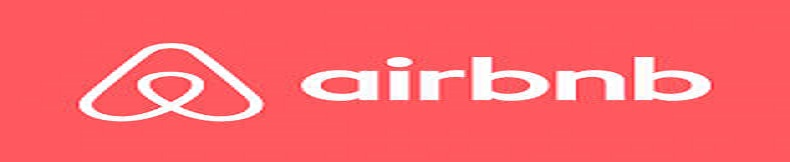

## Import the Necessary Libraries

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Load Airbnb Dataset

In [3]:
Airbnb_df=pd.read_csv("G:/01 Data Analyst/Data Analyst Project/Pr. 1 Airbnb Booking Analysis/Airbnb NYC 2019.csv")
Airbnb_df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


## About the dataset - Airbnb Booking
*   This Airbnb dataset contains nearly 49,000 observations from New York , with 16 columns of data.

*   The Data includes both categorical and numeric values, providing a diverse range of information about the listings.

*   This Dataset may be useful for analyzing trends and patterns in the Airbnb market in New York and also gain insights into the preferences and behavior of Airbnb users in the area.

*   This dataset contains information about Airbnb bookings in New York City in 2019. By analyzing this data, you may be able to understand the trends and patterns of Airbnb use in the NYC.

##**UNDERSTAND THE GIVEN VARIABLES**

**Listing_id :-** This is a unique identifier for each listing in the dataset.

**Listing_name :-** This is the name or title of the listing, as it appears on the Airbnb website.

**Host_id :-** This is a unique identifier for each host in the dataset.

**Host_name :-** This is the name of the host as it appears on the Airbnb website.

**Neighbourhood_group :-** This is a grouping of neighborhoods in New York City, such as Manhattan or Brooklyn.

**Neighbourhood :-** This is the specific neighborhood in which the listing is located.

**Latitude :-** This is the geographic latitude of the listing.

**Longitude :-** This is the geographic longitude of the listing.

**Room_type :-** This is the type of room or property being offered, such as an entire home, private room, shared room.

**Price :-** This is the nightly price for the listing, in US dollars.

**Minimum_nights :-** This is the minimum number of nights that a guest must stay at the listing.

**Total_reviews :-** This is the total number of reviews that the listing has received.

**Reviews_per_month :-** This is the average number of reviews that the listing receives per month.

**Host_listings_count :-** This is the total number of listings that the host has on Airbnb.

**Availability_365 :-** This is the number of days in the next 365 days that the listing is available for booking.

## Data Exploration and Data Cleaning 

In [4]:
Airbnb_df.head().T

,0,1,2,3,4
id,2539,2595,3647,3831,5022
name,Clean & quiet apt home by the park,Skylit Midtown Castle,THE VILLAGE OF HARLEM....NEW YORK !,Cozy Entire Floor of Brownstone,Entire Apt: Spacious Studio/Loft by central park
host_id,2787,2845,4632,4869,7192
host_name,John,Jennifer,Elisabeth,LisaRoxanne,Laura
neighbourhood_group,Brooklyn,Manhattan,Manhattan,Brooklyn,Manhattan
neighbourhood,Kensington,Midtown,Harlem,Clinton Hill,East Harlem
latitude,40.64749,40.75362,40.80902,40.68514,40.79851
longitude,-73.97237,-73.98377,-73.9419,-73.95976,-73.94399
room_type,Private room,Entire home/apt,Private room,Entire home/apt,Entire home/apt
price,149,225,150,89,80


In [5]:
# Checking the what are Variable here:
Airbnb_df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [6]:
# So Now first rename few columns for better understanding of variables
rename_col = {"id":"listing_id","name":"listing_name","number_of_reviews":"total_review","calculated_host_listings_count":"host_listing_counts"}

In [7]:
# Use a pandas function to rename the current function
Airbnb_df= Airbnb_df.rename(columns=rename_col)
Airbnb_df.head(2)

,listing_id,listing_name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,total_review,last_review,reviews_per_month,host_listing_counts,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355


In [8]:
# Checking Shape of Airbnb datasets
Airbnb_df.shape

(48895, 16)

In [9]:
# Basic Information about the datasets
Airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   listing_id           48895 non-null  int64  
 1   listing_name         48879 non-null  object 
 2   host_id              48895 non-null  int64  
 3   host_name            48874 non-null  object 
 4   neighbourhood_group  48895 non-null  object 
 5   neighbourhood        48895 non-null  object 
 6   latitude             48895 non-null  float64
 7   longitude            48895 non-null  float64
 8   room_type            48895 non-null  object 
 9   price                48895 non-null  int64  
 10  minimum_nights       48895 non-null  int64  
 11  total_review         48895 non-null  int64  
 12  last_review          38843 non-null  object 
 13  reviews_per_month    38843 non-null  float64
 14  host_listing_counts  48895 non-null  int64  
 15  availability_365     48895 non-null 

In [10]:
# Check duplicate rows in datasets
Airbnb_df.duplicated().sum()

0

In [11]:
# Check Null values of each columns
Airbnb_df.isnull().sum()

listing_id                 0
listing_name              16
host_id                    0
host_name                 21
neighbourhood_group        0
neighbourhood              0
latitude                   0
longitude                  0
room_type                  0
price                      0
minimum_nights             0
total_review               0
last_review            10052
reviews_per_month      10052
host_listing_counts        0
availability_365           0
dtype: int64

In [12]:
# Host_name and listing_name are not that much null values,so first we are good to fill those with some Substitutes in both the colunmns


In [13]:
Airbnb_df["host_name"].fillna("No Name",inplace=True)
Airbnb_df["listing_name"].fillna("unknown",inplace=True)

In [14]:
Airbnb_df[["host_name","listing_name"]].isnull().sum()

host_name       0
listing_name    0
dtype: int64

In [15]:
# Now the columns last_review and reviews_per_month have total 10052 null values each
# Last review columns is not require for our analysis.we are good to drop this columns
# And the review_per_month columns also containing null values and we can simple put 0 reviews by replacing NAN values

In [16]:
Airbnb_df=Airbnb_df.drop(["last_review"],axis=1)

In [17]:
Airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   listing_id           48895 non-null  int64  
 1   listing_name         48895 non-null  object 
 2   host_id              48895 non-null  int64  
 3   host_name            48895 non-null  object 
 4   neighbourhood_group  48895 non-null  object 
 5   neighbourhood        48895 non-null  object 
 6   latitude             48895 non-null  float64
 7   longitude            48895 non-null  float64
 8   room_type            48895 non-null  object 
 9   price                48895 non-null  int64  
 10  minimum_nights       48895 non-null  int64  
 11  total_review         48895 non-null  int64  
 12  reviews_per_month    38843 non-null  float64
 13  host_listing_counts  48895 non-null  int64  
 14  availability_365     48895 non-null  int64  
dtypes: float64(3), int64(7), object(5)
m

In [18]:
Airbnb_df["reviews_per_month"] = Airbnb_df["reviews_per_month"].replace(to_replace=np.nan,value=0).astype("int64")

In [19]:
Airbnb_df["reviews_per_month"].isnull().sum()

0

In [20]:
# So now check dataset columns changed and null values ,last review column removed
Airbnb_df.sample(5)

,listing_id,listing_name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,total_review,reviews_per_month,host_listing_counts,availability_365
40742,31623508,Flex 3 bedroom and super spacious unit in Bush...,26738513,Malachi,Brooklyn,Bushwick,40.69187,-73.91464,Entire home/apt,135,7,0,0,3,204
29776,22896433,Private 1BR Apt in Sunnyside Close to Train & LGA,126184451,Brie,Queens,Sunnyside,40.74526,-73.91355,Entire home/apt,78,4,26,1,1,50
35504,28181575,Airy 1 Bedroom Flat in Vinegar Hill Townhouse,39523758,Nick,Brooklyn,Navy Yard,40.70375,-73.97979,Entire home/apt,150,3,0,0,1,0
9049,6939859,"Nice room, very close to the subway",36388501,Loralee,Brooklyn,Williamsburg,40.70658,-73.93801,Private room,50,3,5,0,1,0
7418,5511067,"Studio in heart of Cobble Hill, BK",28577246,Nick,Brooklyn,Boerum Hill,40.68607,-73.99048,Entire home/apt,85,10,3,0,1,0


In [21]:
# Check unique Value for variables and doing some experiments

In [22]:
# Check Unique value for listing_id
Airbnb_df["listing_id"].nunique()

48895

In [23]:
Airbnb_df["neighbourhood"].nunique()

221

In [24]:
Airbnb_df["neighbourhood_group"].nunique()

5

In [25]:
Airbnb_df["host_name"].nunique()

11453

In [26]:
Airbnb_df["listing_name"].nunique()

47906

In [27]:
# So i Think few listing/property with same names has different hosts in different area

In [28]:
Airbnb_df[Airbnb_df["host_name"] == "David"]["listing_name"].nunique()

402

In [29]:
# SO here Same host David operates differenet 402 listing/property

In [30]:
Airbnb_df[Airbnb_df["listing_name"]==Airbnb_df["host_name"]].head()
# There are few listings where the listing name and the host name are same

,listing_id,listing_name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,total_review,reviews_per_month,host_listing_counts,availability_365
9473,7264659,Olivier,6994503,Olivier,Manhattan,Upper West Side,40.78931,-73.97520,Entire home/apt,200,5,12,0,1,25
10682,8212051,Monty,43302952,Monty,Brooklyn,East Flatbush,40.66383,-73.92706,Shared room,95,2,7,0,1,238
16422,13186374,Sean,35143476,Sean,Brooklyn,Windsor Terrace,40.65182,-73.98043,Entire home/apt,400,7,0,0,1,0
23996,19348168,Cyn,74033595,Cyn,Brooklyn,Bedford-Stuyvesant,40.67850,-73.91478,Private room,75,2,1,0,1,0
24152,19456810,Hillside Hotel,134184451,Hillside Hotel,Queens,Briarwood,40.70454,-73.81549,Private room,93,1,2,0,18,90


## Describe the dataset and removing outliers

In [31]:
Airbnb_df.describe()

,listing_id,host_id,latitude,longitude,price,minimum_nights,total_review,reviews_per_month,host_listing_counts,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,0.806258,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.502767,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.000000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.000000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,1.000000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.000000,327.000000,365.000000


In [32]:
# Price columns is very important so we have to find big outliers in important columns first

<Axes: xlabel='price'>

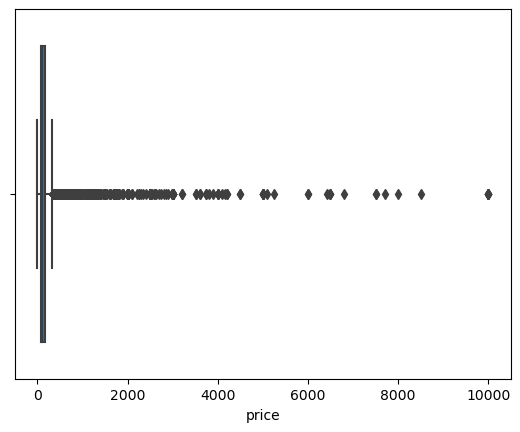

In [33]:
sns.boxplot(x=Airbnb_df["price"])

### Using IQR Technique

In [34]:
# Writing a Outlier function for removing outliers in important columns.
def iqr_technique(dfcolumn):
    Q1=np.percentile(dfcolumn,25)
    Q3=np.percentile(dfcolumn,75)
    IQR=Q3-Q1
    lower_range=Q1-(1.5*IQR)
    upper_range=Q3+(1.5*IQR)
    
    return lower_range,upper_range

In [35]:
lower_bound,upper_bound = iqr_technique(Airbnb_df["price"])
Airbnb_df = Airbnb_df[(Airbnb_df.price>lower_bound) & (Airbnb_df.price<upper_bound)]

<Axes: xlabel='price'>

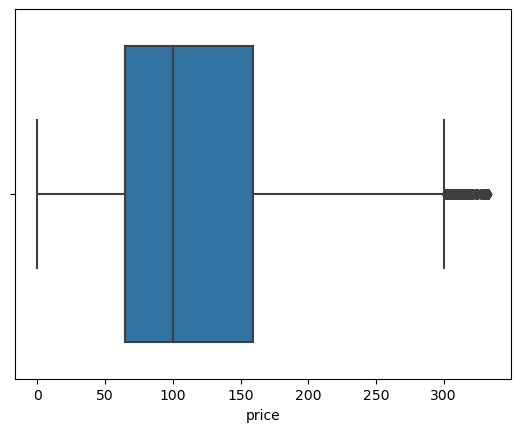

In [36]:
# SO the outlier are removed from price column now check 
sns.boxplot(x=Airbnb_df["price"])

In [37]:
Airbnb_df.shape

(45918, 15)

In [38]:
# See the New Max Price
print(Airbnb_df["price"].max())

333


## Data Visualization

### Q,1 Distribution of Airbnb Booking Price Range using histogram

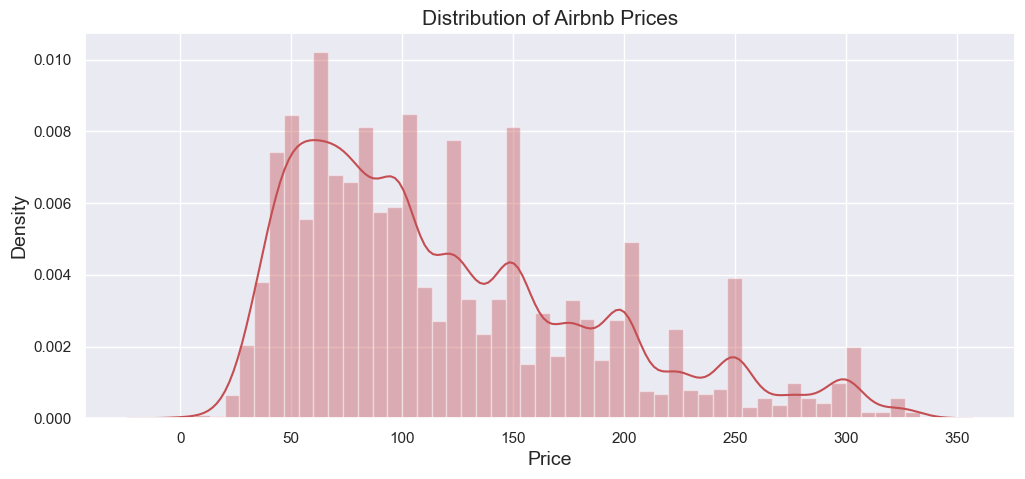

In [40]:
# Create a figure with custome size
plt.figure(figsize=(12,5))

# Create the histogram of the 'price' column of the Airbnb_df dataframe
sns.distplot(Airbnb_df["price"],color='r')

plt.xlabel("Price",fontsize=14)
plt.ylabel("Density",fontsize=14)

plt.title("Distribution of Airbnb Prices",fontsize=15)

plt.show()



In [41]:
# Observations:-
# 1.The range of price being charged on Airbnb appears to be form 20 to 330 dollar,with the majority of listings falling in 
# the price range of 50 to 150 dollars.
# 2.The distribution of prices appears to have a peak in the 50 to 150 dollars range, with a relatively lower density of 
# listings in higher and lower prices range 
# 3.There may be fewer listing available at prices 250 dollars, as the density of listings drops significantly in this range

### Q.2 Total Listing/property count in Each Neighbourhood Group using count plot

In [43]:
# Count the number of listing in each neighbourhood group and store the result in a pandas series
count = Airbnb_df["neighbourhood_group"].value_counts()

# Reset the index of the Seires so that the neighbourhood groups become columns in the resulting dataframe
Top_neighbourhood_group = count.reset_index()

# Rename the columns of the dataframe to be more descrptive 
Top_neighbourhood_group.columns = ["Neighbourhood_Group","Listing_counts"]

Top_neighbourhood_group

,Neighbourhood_Group,Listing_counts
0,Manhattan,19501
1,Brooklyn,19415
2,Queens,5567
3,Bronx,1070
4,Staten Island,365


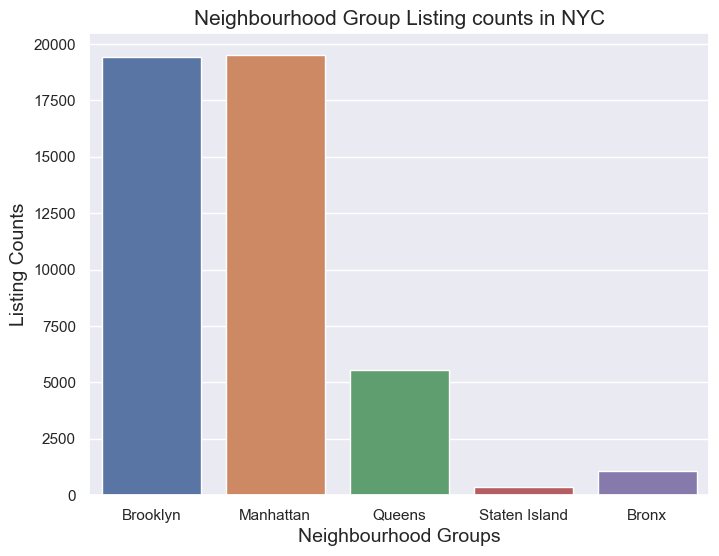

In [47]:
# Set the figure size 
plt.figure(figsize=(8,6))

# Create a count plot of the neighbourhood group data 
sns.countplot(x=Airbnb_df["neighbourhood_group"])

plt.xlabel("Neighbourhood Groups",fontsize=14)
plt.ylabel("Listing Counts",fontsize=14)

plt.title("Neighbourhood Group Listing counts in NYC",fontsize=15)

plt.show()

In [48]:
# Observations:-
# 1.Manhattan and Brooklyn have the highest number of listing on Airbnb, with over 19000 listing each.
# 2.Queens and Bronx have significantly fewer listing compared to Manhattan and Brooklyn,with 5,567 and 1,070 listing respc.
# 3.Staten island has the fewest number of listings, with only 365
# 4.This could suggest that the demand for Airbnb rentals is higher in Manhattan compared to the other neighborhoods, 
# leading to a higher concentration of listings in this area
# 5.Alternatively, it could be that the supply of listings is higher in Manhattan due to a higher number of homeowners or 
# property owners in this neighborhood who are willing to list their properties on Airbnb.

### Q.3 Average price of Each Neighbourhood Group using point plot

In [52]:
# group the Airbnb dataset by Neighbourhood group and calculated the mean of each group
grouped = Airbnb_df.groupby("neighbourhood_group")["price"].mean().reset_index()
grouped.rename(columns={"price":"Avg Price"})

,neighbourhood_group,Avg Price
0,Bronx,77.365421
1,Brooklyn,105.699614
2,Manhattan,145.904620
3,Queens,88.904437
4,Staten Island,89.235616


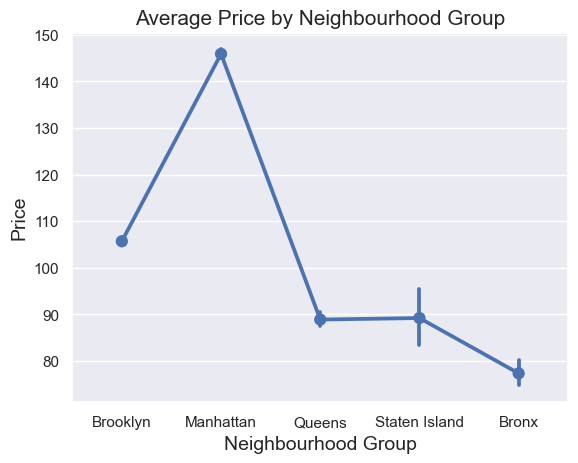

In [62]:
# Import mean function from the Statistical modulo 
from statistics import mean

# Create the point plot 
sns.pointplot(x='neighbourhood_group',y="price",data=Airbnb_df,estimator=np.mean)

plt.xlabel("Neighbourhood Group",fontsize=14)
plt.ylabel("Price",fontsize=14)
plt.title("Average Price by Neighbourhood Group",fontsize=15)

plt.show()

In [63]:
# Observation:-
# 1.The average price of a listing in New York City varies significantly across different neighborhoods, with 
# Manhattan having the highest 146 dollars/day average price and the Bronx having the lowest near 77 dollars/day.
# 2.The average price in queens and Staten Island is relatively similar, despite being in different parts of the city.

### Q.4 Top neighbourhood by listing/property using bar plot 

In [65]:
# Create a new dataFrame that display the top 10 Neighbourhood
Top_neighbourhood = Airbnb_df["neighbourhood"].value_counts()[:10].reset_index().rename(columns={"count":"listing_counts"})
Top_neighbourhood

,neighbourhood,listing_counts
0,Williamsburg,3732
1,Bedford-Stuyvesant,3638
2,Harlem,2585
3,Bushwick,2438
4,Upper West Side,1788
5,Hell's Kitchen,1731
6,East Village,1714
7,Upper East Side,1670
8,Crown Heights,1519
9,Midtown,1143


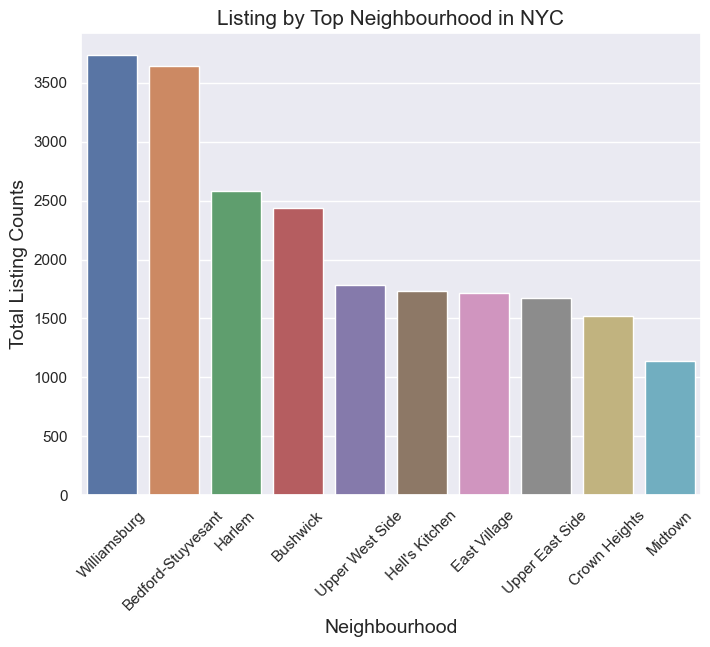

In [74]:
#Get the Top 10 neighbourhood
Top_10_neigh = Airbnb_df["neighbourhood"].value_counts().nlargest(10)

plt.figure(figsize=(8,6))

sns.barplot(x=Top_10_neigh.index,y=Top_10_neigh.values)

plt.xlabel("Neighbourhood",fontsize=14)
plt.ylabel("Total Listing Counts",fontsize=14)
plt.title("Listing by Top Neighbourhood in NYC",fontsize=15)
plt.xticks(rotation=45)

plt.show()

In [75]:
# Observation:-
# 1.The top neighborhoods in New York City in terms of listing counts are Williamsburg, Bedford-Stuyvesant, Harlem, Bushwick,
# and the Upper West Side.
# 2.The top neighborhoods are primarily located in Brooklyn and Manhattan. This may be due to the fact that these boroughs
# have a higher overall population and a higher demand for housing.
# 3.The number of listings alone may not be indicative of the overall demand for housing in a particular neighborhood, as 
# other factors such as the cost of living and the availability of housing may also play a role -->

### Top Hosts With more Listing/property using bar chart 

In [82]:
# Create a new dataframe that display top 10 hosts
top_10 = Airbnb_df["host_name"].value_counts()[:10].reset_index().rename(columns={"count":"Listing_count"})
top_10

,host_name,Listing_count
0,Michael,383
1,David,368
2,John,276
3,Sonder (NYC),272
4,Alex,253
5,Sarah,221
6,Daniel,212
7,Maria,197
8,Jessica,185
9,Mike,184


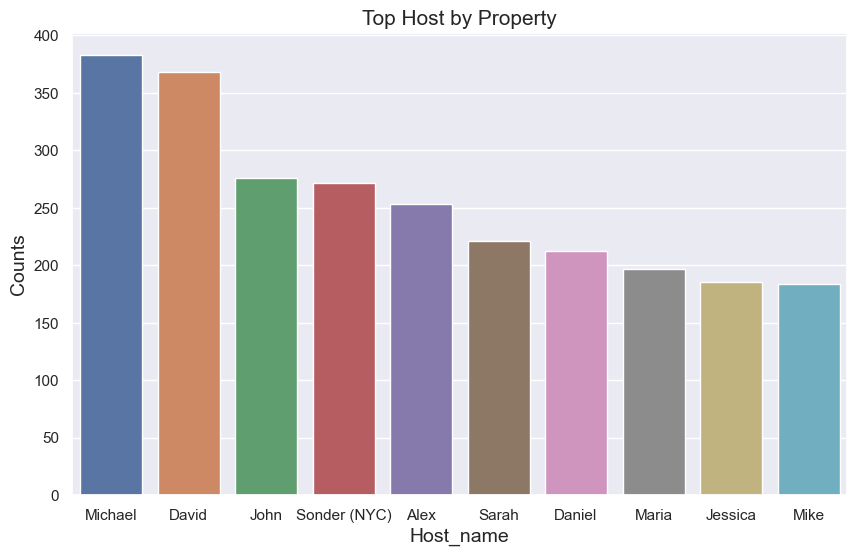

In [85]:
top_10 = Airbnb_df["host_name"].value_counts().nlargest(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_10.index,y=top_10.values)

plt.xlabel("Host_name",fontsize=14)
plt.ylabel("Counts",fontsize=14)
plt.title("Top Host by Property",fontsize=15)

plt.show()


In [86]:
# Observation:-
# 1.The top three hosts in terms of total listings are Michael, David, and John, who have 383, 368, and 276 listings,
# respectively.
# 2.There are relatively few hosts with a large number of listings. This could indicate that the Airbnb market is 
# relatively competitive, with a small number of hosts dominating a large portion of the market.

### Q.5 Number of Active hosts per Location Using Line Chart

In [89]:
# Create a new data Frame that display host per location
host_per_location = Airbnb_df.groupby("neighbourhood_group")["listing_id"].count().reset_index().rename(columns={"listing_id":"Host_counts"})
host_per_location

,neighbourhood_group,Host_counts
0,Bronx,1070
1,Brooklyn,19415
2,Manhattan,19501
3,Queens,5567
4,Staten Island,365


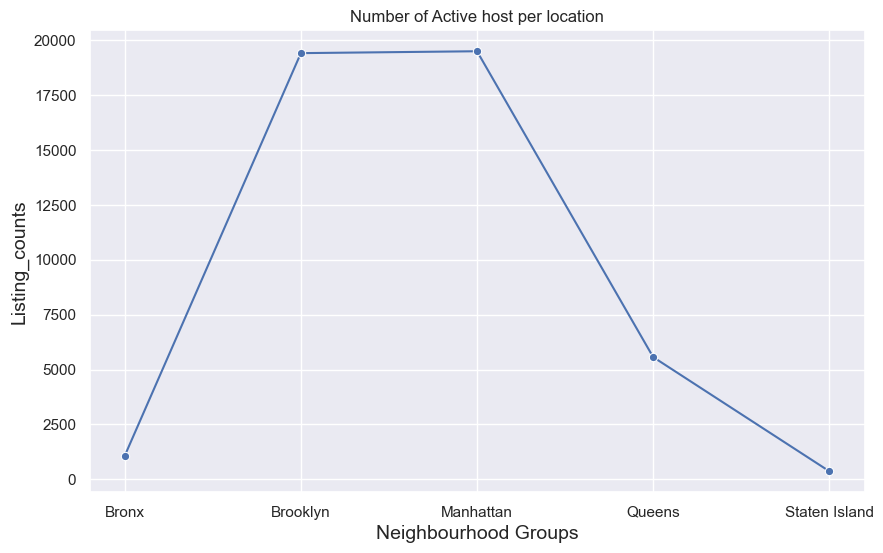

In [93]:
host_per_location = Airbnb_df.groupby("neighbourhood_group")["listing_id"].count()
plt.figure(figsize=(10,6))

sns.lineplot(x=host_per_location.index,y=host_per_location.values,marker="o")

plt.xlabel("Neighbourhood Groups",fontsize=14)
plt.ylabel("Listing_counts",fontsize=14)

plt.title("Number of Active host per location")
plt.show()

In [94]:
# Observation:-
# 1.Manhattan has the largest number of hosts with 19501,Brooklyn has the second largest number of hosts with 19415.
# 2.After that Queens with 5567 and the Bronx with 1070. while Staten Island has the fewest with 365.

### Q.6 Total Count of each room Type

In [100]:
count_room_type = Airbnb_df["room_type"].value_counts().reset_index().rename(columns={"room_type":"Room Type","count":"Counts"})
count_room_type

,Room Type,Counts
0,Entire home/apt,22784
1,Private room,21996
2,Shared room,1138


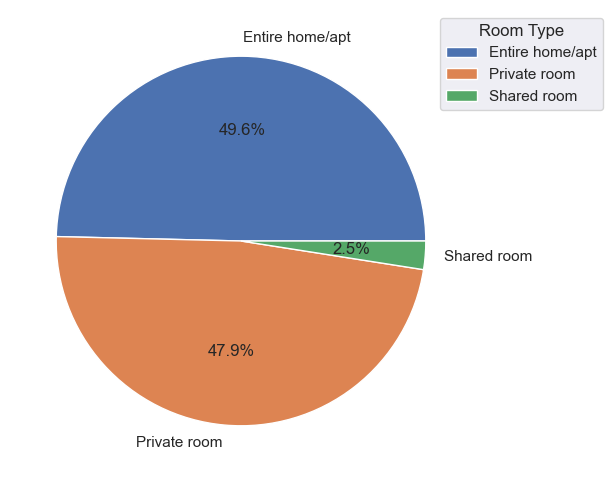

In [104]:
count_room_type = Airbnb_df["room_type"].value_counts()

plt.figure(figsize=(10,6))

plt.pie(count_room_type.values,labels=count_room_type.index,autopct="%1.1f%%")

plt.legend(title="Room Type",bbox_to_anchor=(0.8,0,0.5,1))

plt.show()

In [105]:
# Observation:-
# 1.The majority of listings on Airbnb are for entire homes or apartments, with 22784 listings, followed by private rooms 
# with 21996 listings, and shared rooms with 1138 listings.
# 2.The data suggests that travelers using Airbnb have a wide range of accommodation options to choose from, including 
# privaterooms and entire homes or apartments

### Q.7 Stay Requirment counts by Minimum Nights using bar chart 

In [113]:
top_minimum_nights = Airbnb_df["minimum_nights"].value_counts()[:10].reset_index()
top_minimum_nights

,minimum_nights,count
0,1,12067
1,2,11080
2,3,7375
3,30,3489
4,4,3066
5,5,2821
6,7,1951
7,6,679
8,14,539
9,10,462


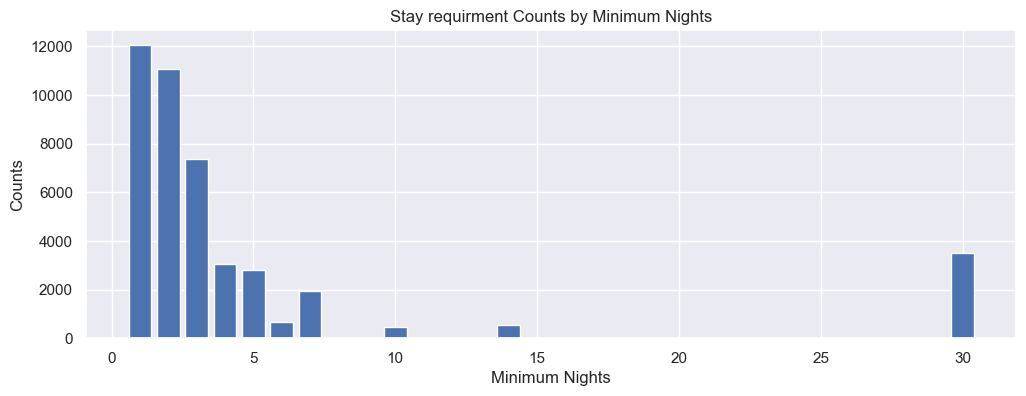

In [117]:
top_minimum_night = Airbnb_df["minimum_nights"].value_counts()[:10]

plt.figure(figsize=(12,4))

plt.bar(x=top_minimum_night.index,height=top_minimum_night.values)

plt.xlabel("Minimum Nights")
plt.ylabel("Counts")
plt.title("Stay requirment Counts by Minimum Nights")
plt.show()

In [118]:
# Observation:-
# 1.The majority of listings on Airbnb have a minimum stay requirement of 1 or 2 nights, with 12067 and 11080 listings, 
# respectively.
# 2.The number of listings with a minimum stay requirement decreases as the length of stay increases, with 7375 listings 
# requiring a minimum stay of 3 nights, and so on

### Q.8 Total Reviews by Each Neighbourhood Group using Pie Chart

In [120]:
review_by_neighbourhoodgroup = Airbnb_df.groupby("neighbourhood_group")["total_review"].sum()
review_by_neighbourhoodgroup

neighbourhood_group
Bronx             28185
Brooklyn         475936
Manhattan        428128
Queens           155719
Staten Island     11536
Name: total_review, dtype: int64

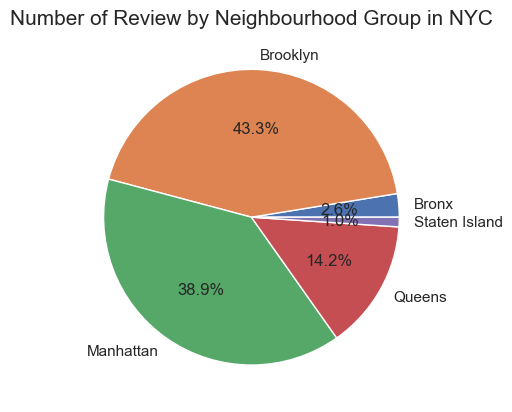

In [122]:
plt.pie(review_by_neighbourhoodgroup.values,labels=review_by_neighbourhoodgroup.index,autopct="%1.1f%%")
plt.title("Number of Review by Neighbourhood Group in NYC",fontsize=15)
plt.show()

In [123]:
# Observation:-
# 1.Brooklyn has the largest share of total reviews on Airbnb, with 43.3%, followed by Manhattan with 38.9%.
# 2.Queens has the third largest share of total reviews, with 14.2%, followed by the Bronx with 2.6% and Staten Island 
# with 1.0%.
# 3.The data suggests that Airbnb is more popular in Brooklyn and Manhattan compared to the other neighborhood groups.


### Maximum review by Each Neighbourhood Groups using pie chart

In [124]:
review_by_neighbourhoodgroup = Airbnb_df.groupby("neighbourhood_group")["total_review"].max()
review_by_neighbourhoodgroup

neighbourhood_group
Bronx            321
Brooklyn         488
Manhattan        607
Queens           629
Staten Island    333
Name: total_review, dtype: int64

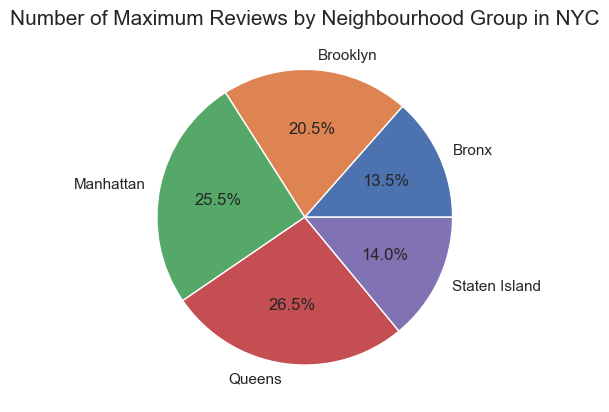

In [125]:
plt.pie(review_by_neighbourhoodgroup.values,labels=review_by_neighbourhoodgroup.index,autopct="%1.1f%%")
plt.title("Number of Maximum Reviews by Neighbourhood Group in NYC",fontsize=15)

plt.show()

In [126]:
# Observation:-
# 1.Queens and Manhattan seem to be the most popular neighborhoods for reviewing, as they have both high number of 
# maximum reviews.
# 2.Queens has the highest percentage of reviews at 26.5%, but it has the third highest number of listings, behind 
# Manhattan and Brooklyn. This suggests that Queens may be a particularly popular destination for tourists or visitors, 
# even though it has fewer listings compared to Manhattan and Brooklyn.
# 3.Overall, this data suggests that Queens, Manhattan, and Brooklyn are the most popular neighborhoods for tourists or 
# visitors, based on the high number of reviews they receive.

### Q.9 Most Reviewed Room Type per month in Neighbourhood Groups

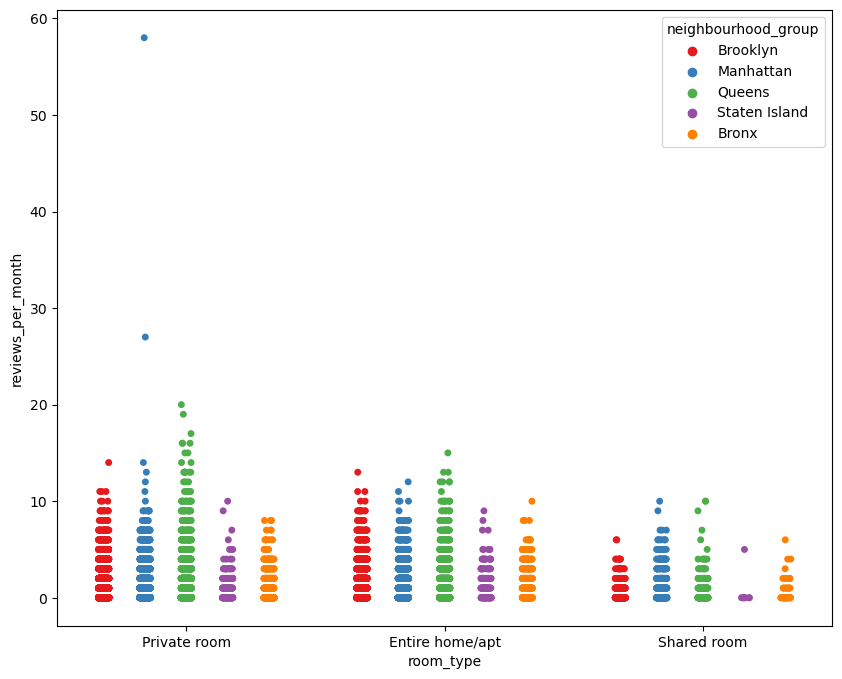

In [41]:
# Create a figure a default size 
f,ax= plt.subplots(figsize=(10,8))
.
ax= sns.stripplot(x="room_type",y="reviews_per_month",hue="neighbourhood_group",dodge=True,data=Airbnb_df,palette="Set1")
plt.show()

<!-- Observation
1.We can see that Private room recieved the most no of reviews/month where Manhattan had the highest reviews received for 
Private rooms with more than 50 reviews/month, followed by Manhattan in the chase.

2.Manhattan & Queens got the most no of reviews for Entire home/apt room type.

3.There were less reviews recieved from shared rooms as compared to other room types and it was from Staten Island followed 
by Bronx. -->

In [42]:
# Observation
# 1.We can see that Private room recieved the most no of reviews/month where Manhattan had the highest reviews received for 
# Private rooms with more than 50 reviews/month, followed by Manhattan in the chase.

# 2.Manhattan & Queens got the most no of reviews for Entire home/apt room type.

# 3.There were less reviews recieved from shared rooms as compared to other room types and it was from Staten Island 
# followed by Bronx.